In [30]:
# Matplotlib maneja las ventanas, las cuadrículas y las capas para pintar elementos gráficos
import matplotlib.pyplot as plt

# Astropy nos provee de unidades físicas ('u') y la clase 'SkyCoord' para definir puntos tridimensionales en el espacio
import astropy.units as u
from astropy.coordinates import SkyCoord

# SunPy procesa mapas del Sol e incluye imágenes reales de calibración/prueba
import sunpy.map
from sunpy.data.sample import AIA_171_IMAGE

# Cargamos el mapa base de prueba usando el filtro AIA de 171 Å (Corona baja a ~1 millón de Kelvin, típicamente color oro/amarillo)
aia = sunpy.map.Map(AIA_171_IMAGE)

In [31]:
# Definimos la esquina superior derecha del recorte usando coordenadas Helioproyectivas en segundos de arco (arcsec)
# frame=aia.coordinate_frame vincula este punto a la misma perspectiva de la cámara del satélite de este mapa
top_right = SkyCoord(0 * u.arcsec, 1000 * u.arcsec, frame=aia.coordinate_frame)

# Definimos la esquina inferior izquierda del recorte (así delimitamos una caja/región de interés)
bottom_left = SkyCoord(-1000 * u.arcsec, 0 * u.arcsec, frame=aia.coordinate_frame)

# .submap() extrae la porción geométrica de la imagen contenida entre esas dos coordenadas físicas
smap = aia.submap(bottom_left, top_right=top_right)

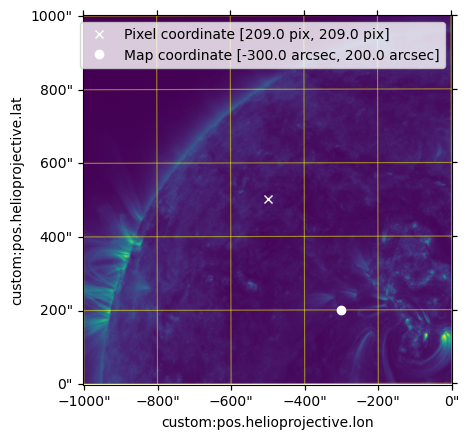

In [34]:
# Creamos la ventana gráfica principal
fig = plt.figure()

# Añadimos el gráfico usando el sistema astronómico WCS del mapa recortado ('smap') para que los bordes muestren grados/arcsec
ax = fig.add_subplot(projection=smap)

# ax.imshow() dibuja los datos numéricos brutos del mapa recortado. 
# Nota técnica: Al usar imshow() plano en lugar de smap.plot(), los colores se procesan según Matplotlib y no el verde/oro estándar de SunPy
ax.imshow(smap.data)

# Añadimos una red o cuadrícula de líneas amarillas semitransparentes (alpha=0.5) que marcan los paralelos y meridianos del espacio solar
ax.coords.grid(color='yellow', linestyle='solid', alpha=0.5)

# Calculamos matemáticamente el centro exacto de la matriz del submapA.
# smap.data.shape[0] es el alto de la matriz y .shape[1] es el ancho. Al dividir entre 2, tenemos el píxel central.
pixel_coord = [smap.data.shape[0]/2., smap.data.shape[1]/2.] * u.pix

# Dibujamos una cruz ('x') blanca en ese píxel exacto. 
# Como Matplotlib por defecto dibuja usando píxeles planos en .plot(), el marcador caerá exactamente en el centro geométrico de la imagen.
ax.plot(pixel_coord[0], pixel_coord[1], 'x', color='white',
        label=f'Pixel coordinate [{pixel_coord[0]}, {pixel_coord[1]}]')

# Definimos un punto físico en el Sol que nos interesa: X = -300 arcsec, Y = 200 arcsec
map_coord = ([-300, 200] * u.arcsec)

# Dibujamos un círculo ('o') blanco usando la física astronómica.
# 1. map_coord[...].to('deg'): Convierte los segundos de arco a grados sexagesimales porque es lo que Matplotlib espera internamente.
# 2. transform=ax.get_transform('world'): ¡ESTA ES LA CLAVE! Le dice a Matplotlib: "No pintes esto en los píxeles de la pantalla; 
#    usa el motor WCS de SunPy para calcular en qué píxel cae esta coordenada física del espacio y píntalo ahí".
ax.plot(map_coord[0].to('deg'), map_coord[1].to('deg'), 'o', color='white',
        transform=ax.get_transform('world'),
        label=f'Map coordinate [{map_coord[0]}, {map_coord[1]}]')

# Activamos la leyenda en la esquina del gráfico para identificar qué es la Cruz (Píxel) y qué es el Círculo (Coordenada Astronómica)
ax.legend()

# Renderizamos y mostramos la ventana en pantalla
plt.show()